# Introduction to TimeSeries Forecasting with ETS

In this workshop, we will explore various **ETS** models for TimeSeries forecasting. 

**ETS** stands for:
- Error
- Trend
- Seasonality

With ETS modelling, we break down a TimeSeries into these three components and then forecast each component.

- [Import](#import) the required packages and read the data
- [Split](#split) the data into train and test datasets
- [Base Model](#base)
- [Simple Exponential Smoothing](#ses)
- [Holt Linear](#holt)
- [Holt-Winters](#holtwinters)

---
<a id="import"></a>
# Import required packages and read data

First, we will import the packages that we will need later.
<dl>
    <dt>pandas</dt>
        <dd>Creates the data tables and series data structures, which we will use to do our analysis</dd>
        <dd>We import this package and give it an alias pd</dd>
    <dt>matplotlib</dt>
        <dd>This is a plotting library for python, which we will use for plotting charts.</dd>
        <dd>We import a subpackage called pyplot and give it an alias plt</dd>
    <dt>statsmodels</dt>
        <dd>This is a statistical library for python, which we will use for building models.</dd>
        <dd>We import a subpackage called tsa.holtwinters</dd>
</dl>

In [1]:
# Import the required packages

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

In [2]:
# Read the data and create the TimeSeries

df = pd.read_csv("airline_passengers.csv")
thousand_passengers = df['Thousands of Passengers']

thousand_passengers.index = pd.DatetimeIndex(df['Month'],freq = 'MS')
                            # here we specify the freq explicitly - see the ref table below
                            # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
thousand_passengers

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: Thousands of Passengers, Length: 144, dtype: int64

<AxesSubplot:xlabel='Month'>

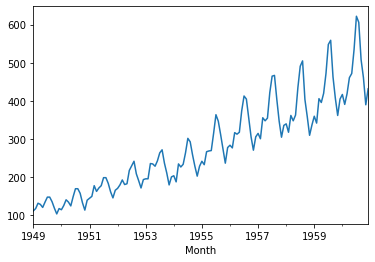

In [3]:
## Plot the number of passengers (in thousands) over time

thousand_passengers.plot()

---
<a id="split"></a>
# Split the data into training and testing subsets

Next, we split the data into a training dataset and a testing dataset. We use *train_data* to build the model and *test_data* to evaluate the model.

When working with a TimeSeries, we typically take the first 80% of data as training and 20% for testing. In this case, I will take up to 1958 as train and the rest as test.

In [4]:
# Test train split 

train_data =  thousand_passengers[:'1958']
test_data = thousand_passengers['1959':]

---
<a id="base"></a>
# Base Model

In statistics, it is common to take the mean of the data to be the best guess (or least-worst guess) for what will happen next. In a TimeSeries, there is an order to the data, so at **each time step** the **running average** is our best guess for what will happen next.

This becomes our **base model** for TimeSeries forecasting.

<AxesSubplot:xlabel='Month'>

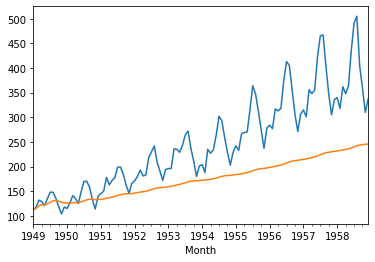

In [5]:
base_model = train_data.expanding().mean()

train_data.plot()
base_model.plot()

Next, we try to forecast the test data based only off the train data. In this case, the best guess is the mean of all the train data. So adding a forecast to our plot, we get the below.

In [6]:
forecast = pd.Series([train_data.mean()] * len(test_data))
forecast.index = test_data.index

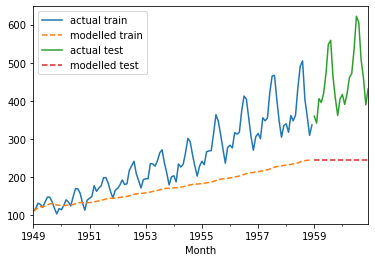

In [7]:
train_data.plot()
base_model.plot(style='--')
test_data.plot()
forecast.plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [8]:
# Average Squared Error for the train_data

squared_errors = (train_data - base_model)**2
ase_train = squared_errors.sum()

In [9]:
# Average Squared Error for the test_data

squared_errors = (test_data - forecast)**2
ase_test = squared_errors.sum()

*Make a note of these for later. We will use the Average Squared Error (ASE) for each model as a measure of fit.*

In [10]:
model_results = {
    'base_model': [ase_train, ase_test]    
}

In this model, the final forecast is completely wrong! This seems to be because the data at the beginning is too highly weighted. In the Simple Exponential Smoothing model, we use a weighting parameter to down-play the impact of earlier values.

---
<a id="ses"></a>
# Simple Exponential Smoothing

In the Simple Exponential Smoothing (SES) model, the best next guess is the **weighted average** (with weight alpha) of all the data that came before. Python will calculate the optimal weight for the best model fit.

The documentation for the Simple Exponential Smoothing model is [here](https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.SimpleExpSmoothing.html).

In [11]:
# Build the model using the training data and print the model summary

ses_model = SimpleExpSmoothing(
    train_data, 
    initialization_method = 'estimated'
).fit()
ses_model.summary()

Dep. Variable:,Thousands of Passengers,No. Observations:,120
Model:,SimpleExpSmoothing,SSE,98475.027
Optimized:,True,AIC,809.208
Trend:,None,BIC,814.783
Seasonal:,None,AICC,809.556
Seasonal Periods:,None,Date:,"Fri, 29 Oct 2021"
Box-Cox:,False,Time:,10:34:12
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9950000,alpha,True
initial_level,118.46667,l.0,True


---
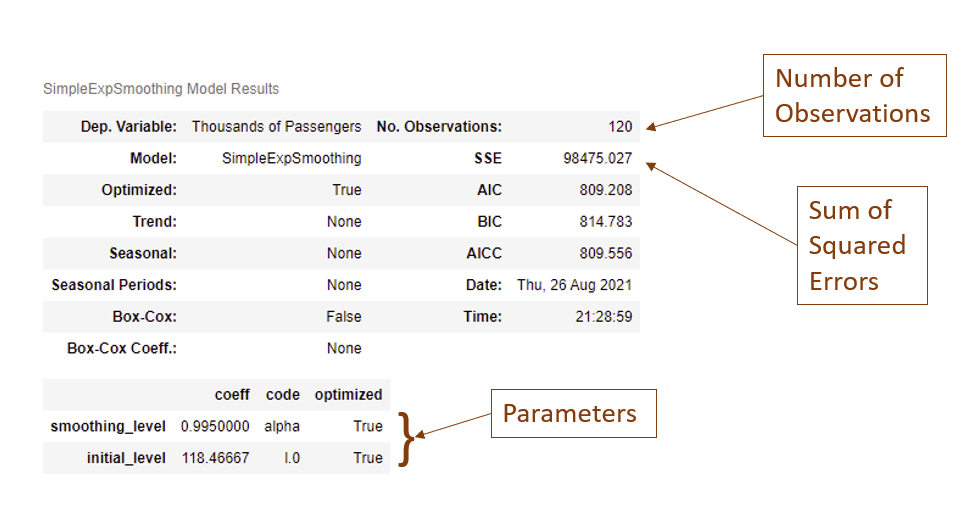

---

<AxesSubplot:xlabel='Month'>

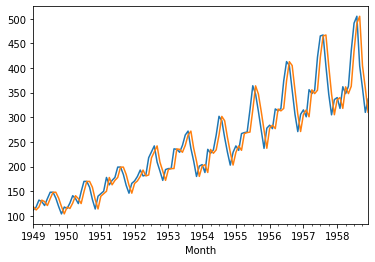

In [12]:
## Plot the training data and the model fitted values

train_data.plot()
ses_model.fittedvalues.plot() 

Next, we try to forecast the test data based only off the train data. In this case, the best guess is the weighted mean of all the train data. So adding a forecast to our plot, we get the below.

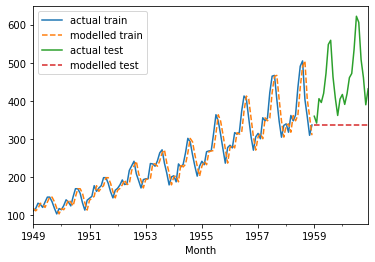

In [13]:
train_data.plot()
ses_model.fittedvalues.plot(style='--')
test_data.plot()
ses_model.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [14]:
# Average Squared Error for the train_data

squared_errors = (train_data - ses_model.fittedvalues)**2
ase_train = squared_errors.sum()

In [15]:
# Average Squared Error for the test_data

squared_errors = (test_data - ses_model.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

*Make a note of these for later. We will use the Average Squared Error (ASE) for each model as a measure of fit.*

In [16]:
model_results['ses_model'] = [ase_train, ase_test]

In this model, the model fits the train data very well, but is a bad fit for the test data! This seems to be because the data is trending upwards, while the model stays static. In the Holt Linear model, we will add a Trend to our model so that it better fits the data.

However, as our model gets more complex, we will need to watch the number of parameters. In order for our model to be **robust** (trustworthy), we need to have at least around **30 data points per parameter**.

In [17]:
# Exercise: Add the number of data points per parameter to the model_results dictionary for each model



---
<a id="holt"></a>
# Holt Linear Model

In the Holt Linear Model, the data is split into Level and Trend. The best next guess for each is the **weighted average** of the data that came before (with weights alpha, beta respectively). Python will calculate the optimal weights for the best model fit.

In [18]:
# Build the model using the training data and print the model summary

holtlinear_model = Holt(
    train_data,
    exponential = False,
    damped_trend = False,
    initialization_method = 'estimated'
).fit()
holtlinear_model.summary()

Dep. Variable:,Thousands of Passengers,No. Observations:,120
Model:,Holt,SSE,98090.127
Optimized:,True,AIC,812.738
Trend:,Additive,BIC,823.888
Seasonal:,None,AICC,813.481
Seasonal Periods:,None,Date:,"Fri, 29 Oct 2021"
Box-Cox:,False,Time:,10:34:13
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9950000,alpha,True
smoothing_trend,0.0001,beta,True


<AxesSubplot:xlabel='Month'>

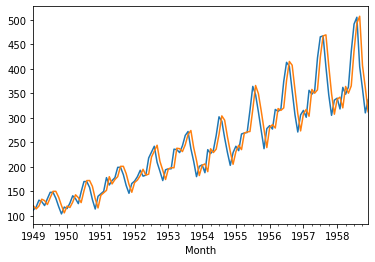

In [19]:
# Plot the training data and the model fitted values

train_data.plot()
holtlinear_model.fittedvalues.plot() 

Next, we try to forecast the test data based only off the train data. In this case, we guess that the trend will continue.

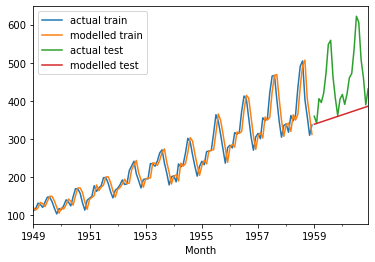

In [20]:
train_data.plot()
holtlinear_model.fittedvalues.plot() 
test_data.plot()
holtlinear_model.forecast(len(test_data)).plot()
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [21]:
# Average Squared Error for the train_data

squared_errors = (train_data - holtlinear_model.fittedvalues)**2
ase_train = squared_errors.sum()

In [22]:
# Average Squared Error for the test_data

squared_errors = (test_data - holtlinear_model.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

*Make a note of these for later. We will use the Average Squared Error (ASE) for each model as a measure of fit.*

In [23]:
model_results['holt_model'] = [ase_train, ase_test]

In this model, the model fits the train data very well and is starting to get better at fitting the test data but it's still missing something in the forecast. This seems to be because the data has a seasonal pattern, while the model does not. In the Holt-Winters model, we will add a Seasonality to our model so that it better fits the data.

However, as our model gets more complex, we will need to watch the number of parameters. In order for our model to be **robust** (trustworthy), we need to have at least around **30 data points per parameter**.

In [24]:
# Exercise: Add the number of data points per parameter to the model_results dictionary for each model



---
<a id="holtwinters"></a>
# Holt-Winters Model

In the Holt-Winters Model, the data is split into Level, Trend and Seasonality (with period m). The best next guess for each is based on the weighted average of the data that came before (with weights alpha, beta, gamma respectively). Python will calculate the optimal weights for the best model fit.

In [25]:
## Build the model using the training data and print the model summary

holtwinters_model = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='add',
    seasonal_periods=12, 
    damped_trend=False,
    initialization_method = 'estimated'
).fit()
holtwinters_model.summary()

Dep. Variable:,Thousands of Passengers,No. Observations:,120
Model:,ExponentialSmoothing,SSE,16033.976
Optimized:,True,AIC,619.397
Trend:,Additive,BIC,663.997
Seasonal:,Additive,AICC,626.169
Seasonal Periods:,12,Date:,"Fri, 29 Oct 2021"
Box-Cox:,False,Time:,10:34:14
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2367563,alpha,True
smoothing_trend,2.9497e-06,beta,True


For this model, we can see that there are now **17 parameters** and only **120 data points**. For a model to be robust, we require at least around **30 data points per parameter** but here we only have about 7. Therefore this model is **not** robust.

In [26]:
# Exercise: How much data would we need in order for this model to be robust?



---
<a id="summary"></a>
# Summary of results

In [27]:
for model, result in  model_results.items():
    print('---')
    print(model)
    print('\t Train ASE:',format(result[0], ",.0f"))
    print('\t Test ASE:', format(result[1], ",.0f"))

---
base_model
	 Train ASE: 1,059,895
	 Test ASE: 1,155,686
---
ses_model
	 Train ASE: 98,475
	 Test ASE: 453,362
---
holt_model
	 Train ASE: 98,090
	 Test ASE: 311,913


Overall, we can see that the Simple Exponential model and the Holt Linear model had similar train Average Squared Errors, but the test ASE for the Holt Linear model is much better (lower ASE means smaller errors).

We therefore accept the Holt Linear model as our TimeSeries forecasting model. We retrain the accepted model using **all** the data and then forecast from there.

In [28]:
# Build the model using all of the data and print the model summary

final_model = Holt(
    thousand_passengers,
    exponential = False,
    damped_trend = False,
    initialization_method = 'estimated'
).fit()
holtlinear_model.summary()

Dep. Variable:,Thousands of Passengers,No. Observations:,120
Model:,Holt,SSE,98090.127
Optimized:,True,AIC,812.738
Trend:,Additive,BIC,823.888
Seasonal:,None,AICC,813.481
Seasonal Periods:,None,Date:,"Fri, 29 Oct 2021"
Box-Cox:,False,Time:,10:34:14
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9950000,alpha,True
smoothing_trend,0.0001,beta,True


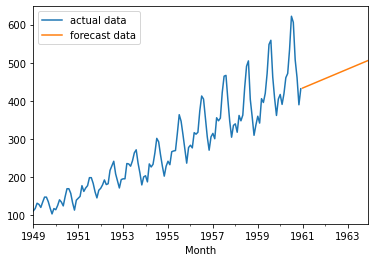

In [29]:
thousand_passengers.plot()
final_model.forecast(36).plot()
plt.legend(['actual data','forecast data'])

---
Reseach Task: Look into the documentation and examine the effect of changing hyperparameters in the model specification, e.g.
> **ExponentialSmoothing**(<br>
&nbsp;    train_data,<br>
&nbsp;    trend='mul', <span style="color:blue"># Try changing this to multiplicative</span><br>
&nbsp;    seasonal='mul', <span style="color:blue"># Try changing this to multiplicative</span><br>
&nbsp;    seasonal_periods=12, <span style="color:blue"># Try changing this to a different number</span><br>
&nbsp;    damped_trend=False, <span style="color:blue"># Try changing this to true</span><br>
&nbsp;    initialization_method = 'estimated'<br>
)

In [30]:
# Exercise: Model the data using a Holt Linear model with multiplicative trend
#     Print the summary results for the new model
#     Is this model better than the additive Holt Linear model?
#     What is it about the data that makes the multiplicative model better than the additive?

